In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from helper import levelset_to_c_binary

# -----------------------------------------
# Paper font settings
# -----------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

In [5]:
# -----------------------------------------
# Grid
# -----------------------------------------
N = 100
L = 1
dx = L / N
Np1 = N + 1
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N
i = np.arange(0, Np1)
x_nodes = i * dx

# Observation receiver locations
Nr = 10
Nrp2 = Nr + 2
i = np.arange(0, Nrp2)
dx_obs = L / (Nr + 1)
ratio_obs_to_discritization = int(dx_obs / dx)
x_nodes_rec = i * dx_obs
recv_idx = (i * ratio_obs_to_discritization)[1:-1]
x_recv = x_nodes[recv_idx]

# Wave speed bounds (level-set)
c_high = np.exp(0.27)
c_low  = np.exp(-0.27)

Nsol, Nobs = 100, 10

data_dir = "./../../Data/Experiment7/"

In [8]:
# -----------------------------------------
# Iterations to load
# iteration_data values that were set in Inference.ipynb
# wavespeed file:  wavespeed_statistics_iteration-{it}.npz  (e.g. --4 for it=-4)
# wave truth file: wave_iteration-{abs(it)}.npz
# -----------------------------------------
iterations_to_load = [ -6, -4, 0]

In [9]:
# -----------------------------------------
# Load all data
# -----------------------------------------
results = {}

for it in iterations_to_load:
    ws_path   = data_dir + f"wavespeed_statistics_iteration-{it}.npz"
    wave_path = data_dir + f"wave_iteration{(it)}.npz"

    ws   = np.load(ws_path)
    wave = np.load(wave_path)

    # wavespeed stats (on x_nodes)
    push_mean_c = ws["push_mean_c"]
    push_std_c  = ws["push_std_c"]
    pcn_mean_c  = ws["pcn_mean_c"]
    pcn_std_c   = ws["pcn_std_c"]

    # true field + observations
    u_true   = wave["u_true"].reshape(Nsol)
    y_dagger = wave["y_obs"].reshape(Nobs, 1)

    # convert true latent field to physical wave speed
    U_true_interp = np.interp(x_nodes, x_center, u_true)
    c_true = levelset_to_c_binary(U_true_interp, c_high=c_high, c_low=c_low)

    results[it] = dict(
        push_mean_c=push_mean_c,
        push_std_c=push_std_c,
        pcn_mean_c=pcn_mean_c,
        pcn_std_c=pcn_std_c,
        c_true=c_true,
        y_dagger=y_dagger,
    )

print("Loaded iterations:", list(results.keys()))

Loaded iterations: [-6, -4, 0]


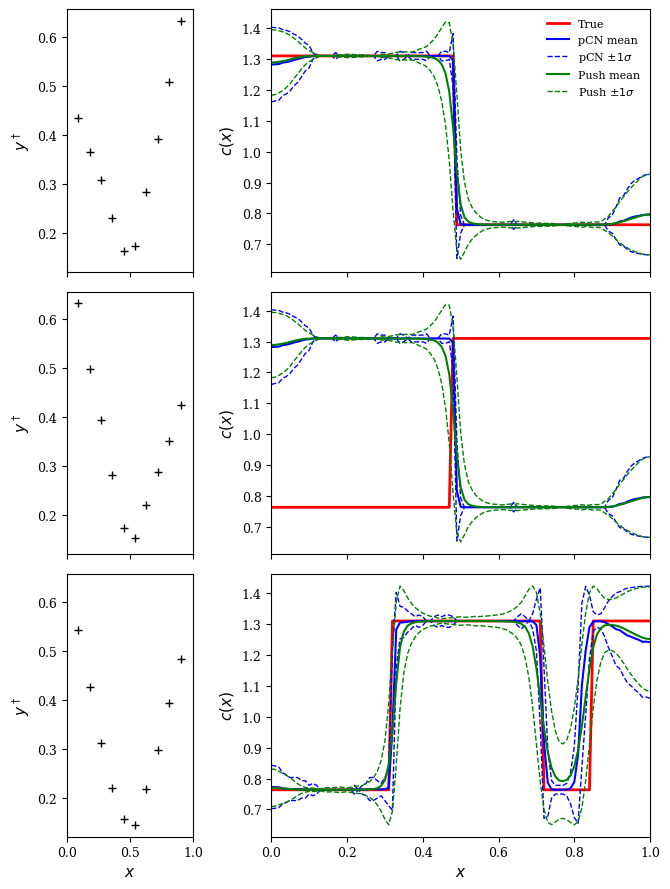

In [10]:
n_rows = len(results)
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(6.8, 3.0 * n_rows),
                         gridspec_kw={"width_ratios": [1, 3]})

# Compute shared ylims across all rows
obs_all = np.concatenate([data["y_dagger"].ravel() for data in results.values()])
obs_ylim = (obs_all.min() - 0.05 * np.ptp(obs_all),
            obs_all.max() + 0.05 * np.ptp(obs_all))

c_all = np.concatenate([
    np.concatenate([
        data["c_true"],
        data["pcn_mean_c"]  + data["pcn_std_c"],
        data["pcn_mean_c"]  - data["pcn_std_c"],
        data["push_mean_c"] + data["push_std_c"],
        data["push_mean_c"] - data["push_std_c"],
    ])
    for data in results.values()
])
c_ylim = (c_all.min() - 0.05 * np.ptp(c_all),
          c_all.max() + 0.05 * np.ptp(c_all))

for row, (it, data) in enumerate(results.items()):
    ax_obs  = axes[row, 0]
    ax_main = axes[row, 1]
    first_row = (row == 0)

    # Left: observations
    ax_obs.plot(x_recv, data["y_dagger"], "+", color="k")
    ax_obs.set_ylabel(r"$y^\dagger$")
    ax_obs.set_xlim([0, 1])
    ax_obs.set_ylim(obs_ylim)
    if row < n_rows - 1:
        ax_obs.set_xticklabels([])
    else:
        ax_obs.set_xlabel(r"$x$")

    # Right: wave speed uncertainty bands
    ax_main.plot(x_nodes, data["c_true"],                             'r-',  lw=2,   label="True" if first_row else "_")
    ax_main.plot(x_nodes, data["pcn_mean_c"],                         'b-',          label="pCN mean" if first_row else "_")
    ax_main.plot(x_nodes, data["pcn_mean_c"] + data["pcn_std_c"],     'b--', lw=1,   label=r"pCN $\pm1\sigma$" if first_row else "_")
    ax_main.plot(x_nodes, data["pcn_mean_c"] - data["pcn_std_c"],     'b--', lw=1)
    ax_main.plot(x_nodes, data["push_mean_c"],                        'g-',          label="Push mean" if first_row else "_")
    ax_main.plot(x_nodes, data["push_mean_c"] + data["push_std_c"],   'g--', lw=1,   label=r"Push $\pm1\sigma$" if first_row else "_")
    ax_main.plot(x_nodes, data["push_mean_c"] - data["push_std_c"],   'g--', lw=1)

    ax_main.set_ylabel(r"$c(x)$")
    ax_main.set_xlim([0, 1])
    ax_main.set_ylim(c_ylim)
    # ax_main.text(0.02, 0.97, f"Iteration {it}", transform=ax_main.transAxes,
    #              fontsize=9, va="top")
    if row < n_rows - 1:
        ax_main.set_xticklabels([])
    else:
        ax_main.set_xlabel(r"$x$")

    if first_row:
        ax_main.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("./../../Figs/Experiment7/wavespeed_all_iterations.png", dpi=300, bbox_inches='tight')
plt.show()